In [1]:
import pandas as pd 

import numpy as np

import scipy.optimize as opt

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('churn.csv')

df = data.copy()

df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,pager,internet,callwait,confer,ebill,loglong,logtoll,Ininc,custcat,churn
0,11,33,7,136,5,5,0,1,1,4.40,1,0,1,1,0,1.482,3.033,4.913,4,1
1,33,33,12,33,2,0,0,0,0,9.45,0,0,0,0,0,2.246,3.240,3.497,1,1
2,23,30,9,30,1,2,0,0,0,6.30,0,0,0,1,1,1.841,3.240,3.401,3,0
3,38,35,5,76,2,10,1,1,1,6.05,1,1,1,1,1,1.800,3.807,4.331,4,0
4,7,35,14,80,2,15,0,1,0,7.10,0,0,0,1,0,1.960,3.091,4.382,3,0


In [3]:
x = df.drop('churn', axis = 1)

y = df[['churn']]

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 7)

In [5]:
scaler = StandardScaler()

x_train_normalize = scaler.fit_transform(x_train)
x_test_normalize = scaler.transform(x_test)

In [12]:
from sklearn.linear_model import LogisticRegression

lregr = LogisticRegression(C = 1 , solver = 'liblinear' )
#solver : liblinear(small), lbfgs(medium and big), newton-cg(intermediate), sag and saga(big)

lregr.fit(x_train_normalize, y_train['churn'])

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [13]:
y_pred = lregr.predict(x_test_normalize)

y_pred_prob = lregr.predict_proba(x_test_normalize)

print(y_pred_prob)

[[0.03364255 0.96635745]
 [0.29231593 0.70768407]
 [0.87437863 0.12562137]
 [0.99361174 0.00638826]
 [0.83762721 0.16237279]
 [0.06244446 0.93755554]
 [0.18569068 0.81430932]
 [0.97003108 0.02996892]
 [0.12106486 0.87893514]
 [0.98276353 0.01723647]
 [0.90288622 0.09711378]
 [0.03100709 0.96899291]
 [0.982311   0.017689  ]
 [0.02031243 0.97968757]
 [0.98704625 0.01295375]
 [0.02011031 0.97988969]
 [0.0107255  0.9892745 ]
 [0.09684128 0.90315872]
 [0.18569068 0.81430932]
 [0.97933892 0.02066108]
 [0.90737978 0.09262022]
 [0.02011031 0.97988969]
 [0.02321656 0.97678344]
 [0.03351037 0.96648963]
 [0.87437863 0.12562137]
 [0.96696407 0.03303593]
 [0.39501836 0.60498164]
 [0.99106296 0.00893704]
 [0.01948436 0.98051564]
 [0.94319794 0.05680206]
 [0.3668886  0.6331114 ]
 [0.57838471 0.42161529]]


In [15]:
from sklearn.metrics import jaccard_score, accuracy_score, classification_report, log_loss

print()
print(f"JACCARD (0): {jaccard_score(y_test, y_pred, pos_label = 0):1.2f}")
print(f"JACCARD (1): {jaccard_score(y_test, y_pred, pos_label = 1):1.2f}")
print()
print(f"ACCURACY: {accuracy_score(y_test, y_pred):1.2f}")
print()
print(f"LOG LOSS: {log_loss(y_test, y_pred_prob):1.2f}") # How much my model is certain 
print()
print()
print()
print(classification_report(y_test, y_pred))


JACCARD (0): 0.78
JACCARD (1): 0.78

ACCURACY: 0.88

LOG LOSS: 0.43



              precision    recall  f1-score   support

           0       0.93      0.82      0.88        17
           1       0.82      0.93      0.88        15

    accuracy                           0.88        32
   macro avg       0.88      0.88      0.88        32
weighted avg       0.88      0.88      0.88        32



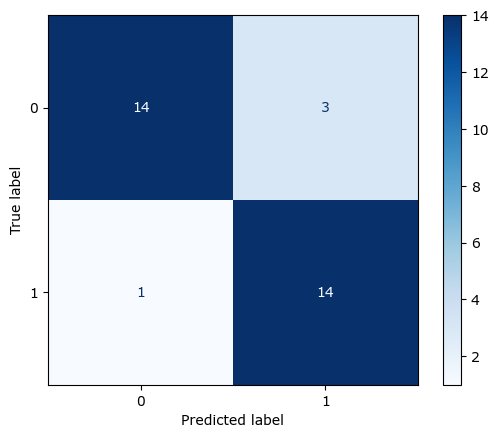

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(lregr, x_test_normalize, y_test, display_labels = lregr.classes_, cmap = plt.cm.Blues)
plt.show()